<a href="https://colab.research.google.com/github/Anuragdixit22081993/my_practice_aiml/blob/main/guru_assignments/bronze_level_3/4_house_price_pred_3d_plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

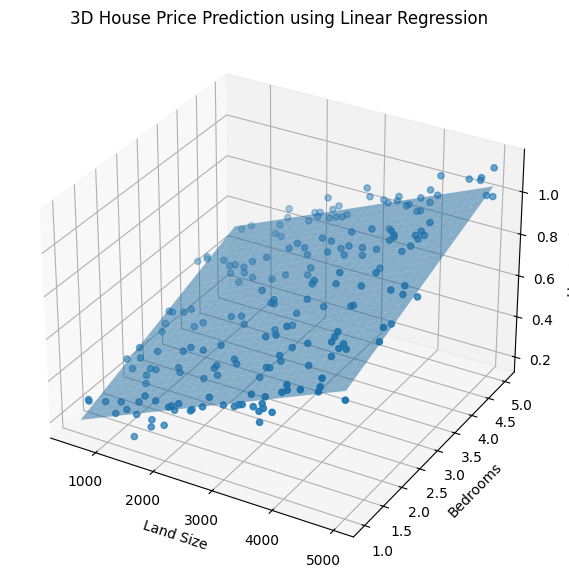

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Read CSV
data = pd.read_csv("https://raw.githubusercontent.com/Anuragdixit22081993/my_practice_aiml/refs/heads/main/guru_assignments/dataset/datasets/house_price_data.csv")

# Features and Target
X = data[["LandSize", "Bedrooms"]]
y = data["Price"]

# Train Model
model = LinearRegression()
model.fit(X, y)

# Create Grid for Surface
land_range = np.linspace(
    data["LandSize"].min(),
    data["LandSize"].max(),
    30
)

bedroom_range = np.linspace(
    data["Bedrooms"].min(),
    data["Bedrooms"].max(),
    30
)

L, B = np.meshgrid(land_range, bedroom_range)

grid = pd.DataFrame({
    "LandSize": L.ravel(),
    "Bedrooms": B.ravel()
})

P = model.predict(grid)
P = P.reshape(L.shape)

# 3D Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Actual Data Points
ax.scatter(
    data["LandSize"],
    data["Bedrooms"],
    data["Price"],
    marker='o'
)

# Prediction Surface
ax.plot_surface(
    L,
    B,
    P,
    alpha=0.5
)

ax.set_xlabel("Land Size")
ax.set_ylabel("Bedrooms")
ax.set_zlabel("House Price")
ax.set_title("3D House Price Prediction using Linear Regression")

plt.show()